In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/deepfake-face-images/Final Dataset/dataset.csv
/kaggle/input/deepfake-face-images/Final Dataset/Fake/fake_639_aug_1.jpg
/kaggle/input/deepfake-face-images/Final Dataset/Fake/1JD6S89G4D.jpg
/kaggle/input/deepfake-face-images/Final Dataset/Fake/1KCN62R2WA.jpg
/kaggle/input/deepfake-face-images/Final Dataset/Fake/1FKIB1PX33.jpg
/kaggle/input/deepfake-face-images/Final Dataset/Fake/0AMO1SB5CD.jpg
/kaggle/input/deepfake-face-images/Final Dataset/Fake/fake_46_aug_3.jpg
/kaggle/input/deepfake-face-images/Final Dataset/Fake/fake_373_aug_3.jpg
/kaggle/input/deepfake-face-images/Final Dataset/Fake/fake_510_aug_2.jpg
/kaggle/input/deepfake-face-images/Final Dataset/Fake/0ICRTX548O.jpg
/kaggle/input/deepfake-face-images/Final Dataset/Fake/fake_61_aug_2.jpg
/kaggle/input/deepfake-face-images/Final Dataset/Fake/fake_649_aug_2.jpg
/kaggle/input/deepfake-face-images/Final Dataset/Fake/fake_436_aug_2.jpg
/kaggle/input/deepfake-face-images/Final Dataset/Fake/fake_211_aug_0.jpg
/kaggle/inpu

In [2]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout, RandomFlip, RandomRotation
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.mixed_precision import set_global_policy
import numpy as np
import pathlib
DATA_DIR = pathlib.Path('/kaggle/input/deepfake-face-images/Final Dataset')

2025-11-04 16:28:37.402178: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762273717.675661      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762273717.763802      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Loading and splitting training data (80%)...
Found 12890 files belonging to 2 classes.
Using 10312 files for training.
Loading and splitting validation data (20%)...


2025-11-04 16:29:00.857390: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 12890 files belonging to 2 classes.
Using 2578 files for validation.
Classes found: ['Fake', 'Real'] (0 = Fake, 1 = Real)

--- Displaying a sample batch from the training dataset ---


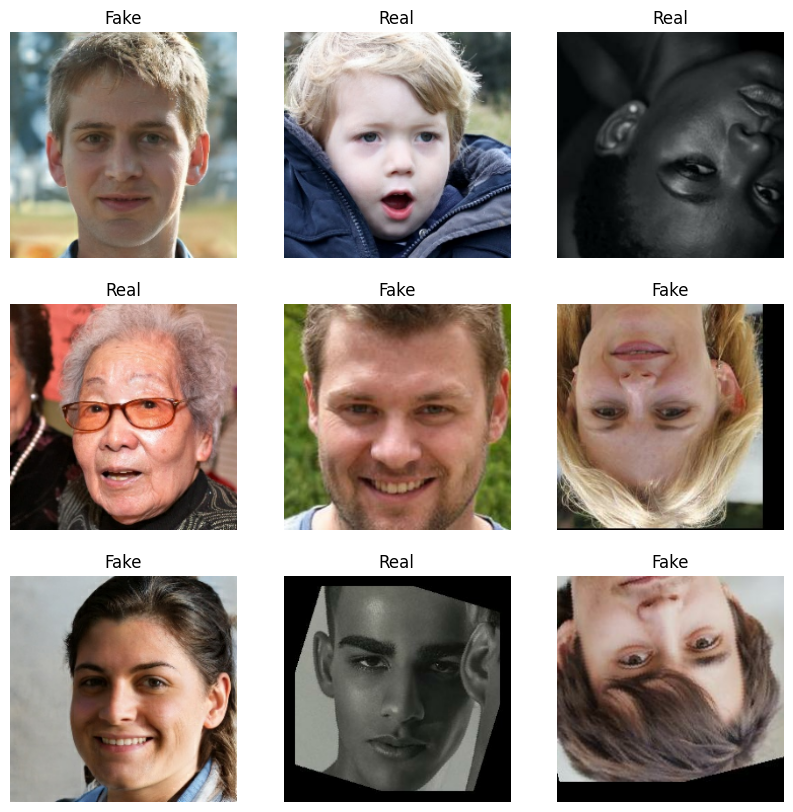

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32 # You can increase this (e.g., 64) if your GPU has enough memory
VALIDATION_SPLIT = 0.2
SEED = 123 # Must be the same seed for train and validation

# --- 3. Load Data and Create Datasets ---
print("Loading and splitting training data (80%)...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

print("Loading and splitting validation data (20%)...")
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

# Get class names
CLASS_NAMES = train_dataset.class_names
print(f"Classes found: {CLASS_NAMES} (0 = {CLASS_NAMES[0]}, 1 = {CLASS_NAMES[1]})")
import matplotlib.pyplot as plt

# --- 4. Visualize a Batch of Training Data ---
print("\n--- Displaying a sample batch from the training dataset ---")

plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1): # Takes one batch
    for i in range(9): # Loops through the first 9 images in the batch
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        # Get the class name
        # labels[i] will be 0 or 1
        # CLASS_NAMES will be ['fake', 'real'] or ['real', 'fake']
        class_index = int(labels[i])
        plt.title(CLASS_NAMES[class_index])
        plt.axis("off")
plt.show()

In [4]:

# --- 4. Configure Datasets for Performance ---
# Use .cache() and .prefetch() to speed up training
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)


# --- 5. Data Augmentation Layer (Unchanged) ---
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
], name="data_augmentation")


# --- 6. Build the Finetuning Model ---
def build_model():
    # 1. Input and Augmentation
    inputs = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3), name="input_layer")
    x = data_augmentation(inputs)
    x = tf.keras.applications.resnet50.preprocess_input(x)

    # 2. The Backbone
    base_model = ResNet50(include_top=False, weights='imagenet', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    
    # 3. Finetuning: Unfreeze the top layers
    base_model.trainable = True
    
    # Freeze the early layers
    # We only want to finetune the high-level layers (conv4 and conv5)
    for layer in base_model.layers:
        if 'conv1' in layer.name or 'conv2' in layer.name or 'conv3' in layer.name or 'conv4' in layer.name:
            layer.trainable = False
            
    # 4. The New Classification Head
    x = base_model(x, training=False) # Set training=False for batchnorm layers
    x = GlobalAveragePooling2D(name="global_avg_pool")(x)
    x = Dropout(0.5, name="head_dropout")(x) # Heavy dropout
    
    # Ensure the output layer is float32 for mixed precision stability
    outputs = Dense(1, activation='sigmoid', dtype='float32', name="output_layer")(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    return model

model = build_model()
model.summary()


# --- 7. Compile the Model ---
# We use a VERY LOW learning rate for finetuning
model.compile(
    optimizer=Adam(learning_rate=1e-5), # <--- CRITICAL
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

# --- 8. Train the Model ---
print("\n--- Starting Model Finetuning ---")
EPOCHS = 10 

history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=validation_dataset
    # Note: class_weight argument is REMOVED as dataset is balanced
)

print("Training complete.")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_avg_pool     │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dropout        │ (None, 2048)      │          0 │ global_avg_pool[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_layer        │ (None, 1)         │      2,049 │ head_dropout[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 14,978,049 (57.14 MB)

 Non-trainable params: 8,611,712 (32.85 MB)


--- Starting Model Finetuning ---
Epoch 1/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 1606s 5s/step - accuracy: 0.6494 - loss: 0.6337 - precision: 0.6182 - recall: 0.6278 - val_accuracy: 0.8367 - val_loss: 0.3448 - val_precision: 0.8499 - val_recall: 0.7866
Epoch 2/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 1539s 5s/step - accuracy: 0.8048 - loss: 0.3987 - precision: 0.8115 - recall: 0.7440 - val_accuracy: 0.8805 - val_loss: 0.2786 - val_precision: 0.8787 - val_recall: 0.8611
Epoch 3/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 1534s 5s/step - accuracy: 0.8531 - loss: 0.3229 - precision: 0.8518 - recall: 0.8204 - val_accuracy: 0.9007 - val_loss: 0.2349 - val_precision: 0.8717 - val_recall: 0.9213
Epoch 4/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 1549s 5s/step - accuracy: 0.8865 - loss: 0.2560 - precision: 0.8825 - recall: 0.8664 - val_accuracy: 0.9213 - val_loss: 0.1929 - val_precision: 0.9052 - val_recall: 0.9272
Epoch 5/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 1583s 5s/step - accuracy: 0.9139 - loss: 0.2083 - precision: 0.9114 - recall:

In [5]:
print("\n--- Training Finished. Saving Model... ---")

# This saves the entire model (architecture, weights, optimizer)
# to the /kaggle/working/ directory.
model.save('my_deepfake_detector.keras')

print("--- Model Saved Successfully to /kaggle/working/ ---")


--- Training Finished. Saving Model... ---
--- Model Saved Successfully to /kaggle/working/ ---
